In [1]:
#Redirecting to Project Base

import os 
import sys
from pathlib import Path
BASE = Path.cwd().parent.parent.parent
sys.path.insert(0, str(BASE))

In [2]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

#Importing Classes
from src.data import Data

/Users/rohit/venv/time-series-venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_handler = Data()

Loading data...
Data loaded succesfully!


In [4]:
product_id = 'HOBBIES_1_067_CA_1_validation'

In [5]:
df = data_handler.get_train_data(product_id, choice = 'single_prod_day_wise')

In [6]:
df.T

,65
d_1,0
d_2,7
d_3,6
d_4,7
d_5,4
...,...
d_1909,0
d_1910,0
d_1911,4
d_1912,4


In [7]:
sales = df.iloc[0].values

In [8]:
sales

array([0, 7, 6, ..., 4, 4, 2], shape=(1913,))

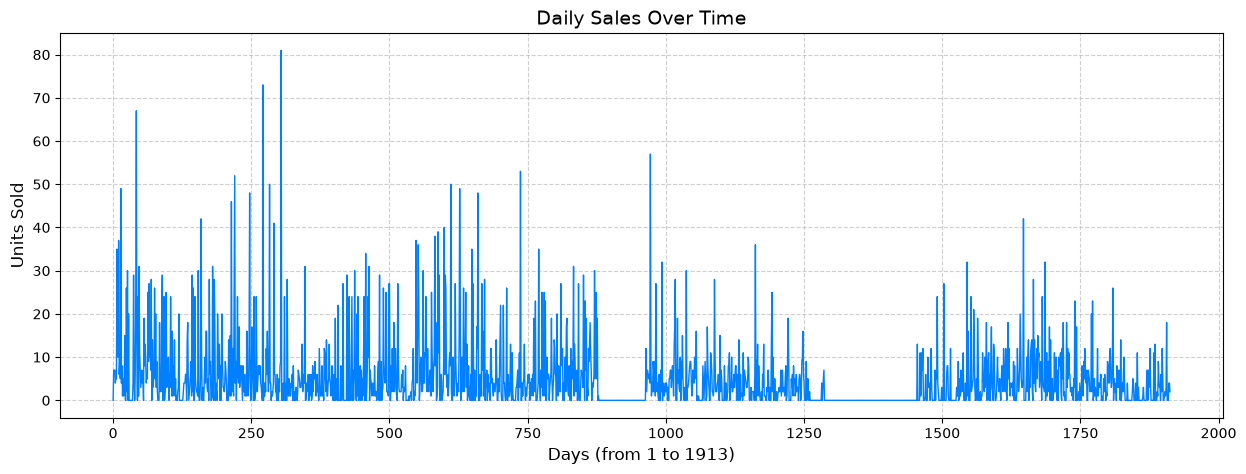

In [9]:
plt.figure(figsize=(15, 5))
plt.plot(sales, color="#0080ff", linewidth=1)

plt.title("Daily Sales Over Time", fontsize=14)
plt.xlabel("Days (from 1 to 1913)", fontsize=12)
plt.ylabel("Units Sold", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [10]:
sales_series = pd.Series(sales)

In [12]:
from statsmodels.tsa.stattools import adfuller


def perform_adf_test(series: pd.Series):
    clean_series = series.dropna()
    adf_result = adfuller(clean_series, autolag="AIC")
    print("=" * 40)
    print("Augmented Dickey-Fuller (ADF) Test")
    print("=" * 40)
    print(f"ADF Statistic:      {adf_result[0]:.4f}")
    print(f"p-value:            {adf_result[1]:.4f}")
    print(f"Lags Used:          {adf_result[2]}")
    print(f"Observations:       {adf_result[3]}")
    print("Critical Values:")
    for key, value in adf_result[4].items():
        print(f"   {key}: {value:.4f}")

    # Interpretation
    p_val = adf_result[1]
    if p_val <= 0.05:
        print(
            f"\nResult: Stationary (p-value = {p_val:.4f} <= 0.05, Reject Null Hypothesis)"
        )
    else:
        print(
            f"\nResult: Non-Stationary (p-value = {p_val:.4f} > 0.05, Fail to Reject Null Hypothesis)"
        )


# Example Usage:
# perform_adf_test(df['sales_column'])

In [13]:
result = perform_adf_test(sales_series)

Augmented Dickey-Fuller (ADF) Test
ADF Statistic:      -4.5822
p-value:            0.0001
Lags Used:          23
Observations:       1889
Critical Values:
   1%: -3.4338
   5%: -2.8631
   10%: -2.5676

Result: Stationary (p-value = 0.0001 <= 0.05, Reject Null Hypothesis)
